In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from tslearn.metrics import cdist_dtw, dtw
from tslearn.barycenters import dtw_barycenter_averaging


In [ ]:
target_mmsi = 311014800
target_noise_subcluster = 2

candidate_clusters = [0, 2, 17, 18, 21, 22, 23]

In [4]:
X_raw = np.load("X_w50_raw.npy", allow_pickle=False)
X_scaled = np.load("X_w50_scaled.npy", allow_pickle=False)

labels_all = np.load("full_hdbscan_labels_all_80.npy")
full_meta = pd.read_csv("full_hdbscan_metadata_80.csv")

noise_labels = np.load("triuksmai_80_hdbscan_20_5_labels.npy")
noise_meta = pd.read_csv("triuksmai_80_metadata_hdbscan_20_5.csv")

if "hdbscan_cluster" not in full_meta.columns and "cluster" in full_meta.columns:
    full_meta = full_meta.rename(columns={"cluster": "hdbscan_cluster"})

if "noise_subcluster" not in noise_meta.columns:
    noise_meta["noise_subcluster"] = noise_labels

print("X_raw:", X_raw.shape)
print("X_scaled:", X_scaled.shape)
print("labels_all:", labels_all.shape)
print("full_meta:", full_meta.shape)
print("noise_labels:", noise_labels.shape)
print("noise_meta:", noise_meta.shape)

if len(labels_all) != len(X_raw):
    raise ValueError("KLAIDA: labels_all ir X_raw ilgiai nesutampa.")

if len(noise_labels) != len(noise_meta):
    raise ValueError("KLAIDA: noise_labels ir noise_meta ilgiai nesutampa.")

print("\nTriukšmo subklasterių dydžiai:")
display(
    noise_meta["noise_subcluster"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"index": "noise_subcluster", "noise_subcluster": "n_sequences"})
)

X_raw: (55432, 50, 5)
X_scaled: (55432, 50, 6)
labels_all: (55432,)
full_meta: (55432, 16)
noise_labels: (2777,)
noise_meta: (2777, 20)

Triukšmo subklasterių dydžiai:


,n_sequences,count
0,-1,1246
1,0,18
2,1,643
3,2,825
4,3,45


In [5]:
print("Tiriamas MMSI:", target_mmsi)

print("\nPilname 80 % HDBSCAN rezultate:")
display(
    full_meta[
        full_meta["mmsi"].astype(str) == str(target_mmsi)
    ]
)

print("\n80 % triukšmo vidiniame HDBSCAN:")
display(
    noise_meta[
        noise_meta["mmsi"].astype(str) == str(target_mmsi)
    ]
)

noise_sub_meta = noise_meta[
    noise_meta["noise_subcluster"] == target_noise_subcluster
].copy()

print("\nAnalizuojamas triukšmo subklasteris:", target_noise_subcluster)
print("Sekų kiekis:", len(noise_sub_meta))
print("Unikalių MMSI:", noise_sub_meta["mmsi"].nunique())

cluster_sizes = []

for k in candidate_clusters:
    n = np.sum(labels_all == k)
    cluster_sizes.append({
        "hdbscan_cluster": k,
        "n_sequences": n
    })

cluster_sizes = pd.DataFrame(cluster_sizes)

print("\nLyginami originalūs HDBSCAN klasteriai:")
display(cluster_sizes)

Tiriamas MMSI: 311014800

Pilname 80 % HDBSCAN rezultate:


,sequence_id,mmsi,block_id,start_time,end_time,window_start_idx,window_end_idx,center_x,center_y,x_bin,y_bin,stratum,is_forced_vessel,global_idx,source,hdbscan_cluster
40469,40469,311014800,1,2025-05-17 07:56:00,2025-05-17 09:34:00,0,49,-0.015799,-0.004248,13.0,13.0,13_13,True,40469,sample,-1



80 % triukšmo vidiniame HDBSCAN:


,noise_row,sequence_id,mmsi,block_id,start_time,end_time,window_start_idx,window_end_idx,center_x,center_y,x_bin,y_bin,stratum,is_forced_vessel,source,source_row,global_idx,hdbscan_cluster,noise_subcluster,subcluster_probability
1567,1567,40469,311014800,1,2025-05-17 07:56:00,2025-05-17 09:34:00,0,49,-0.015799,-0.004248,13.0,13.0,13_13,True,sample,4009,40469,-1,2,0.576739



Analizuojamas triukšmo subklasteris: 2
Sekų kiekis: 825
Unikalių MMSI: 293

Lyginami originalūs HDBSCAN klasteriai:


,hdbscan_cluster,n_sequences
0,0,3096
1,2,2485
2,17,598
3,18,929
4,21,711
5,22,576
6,23,300


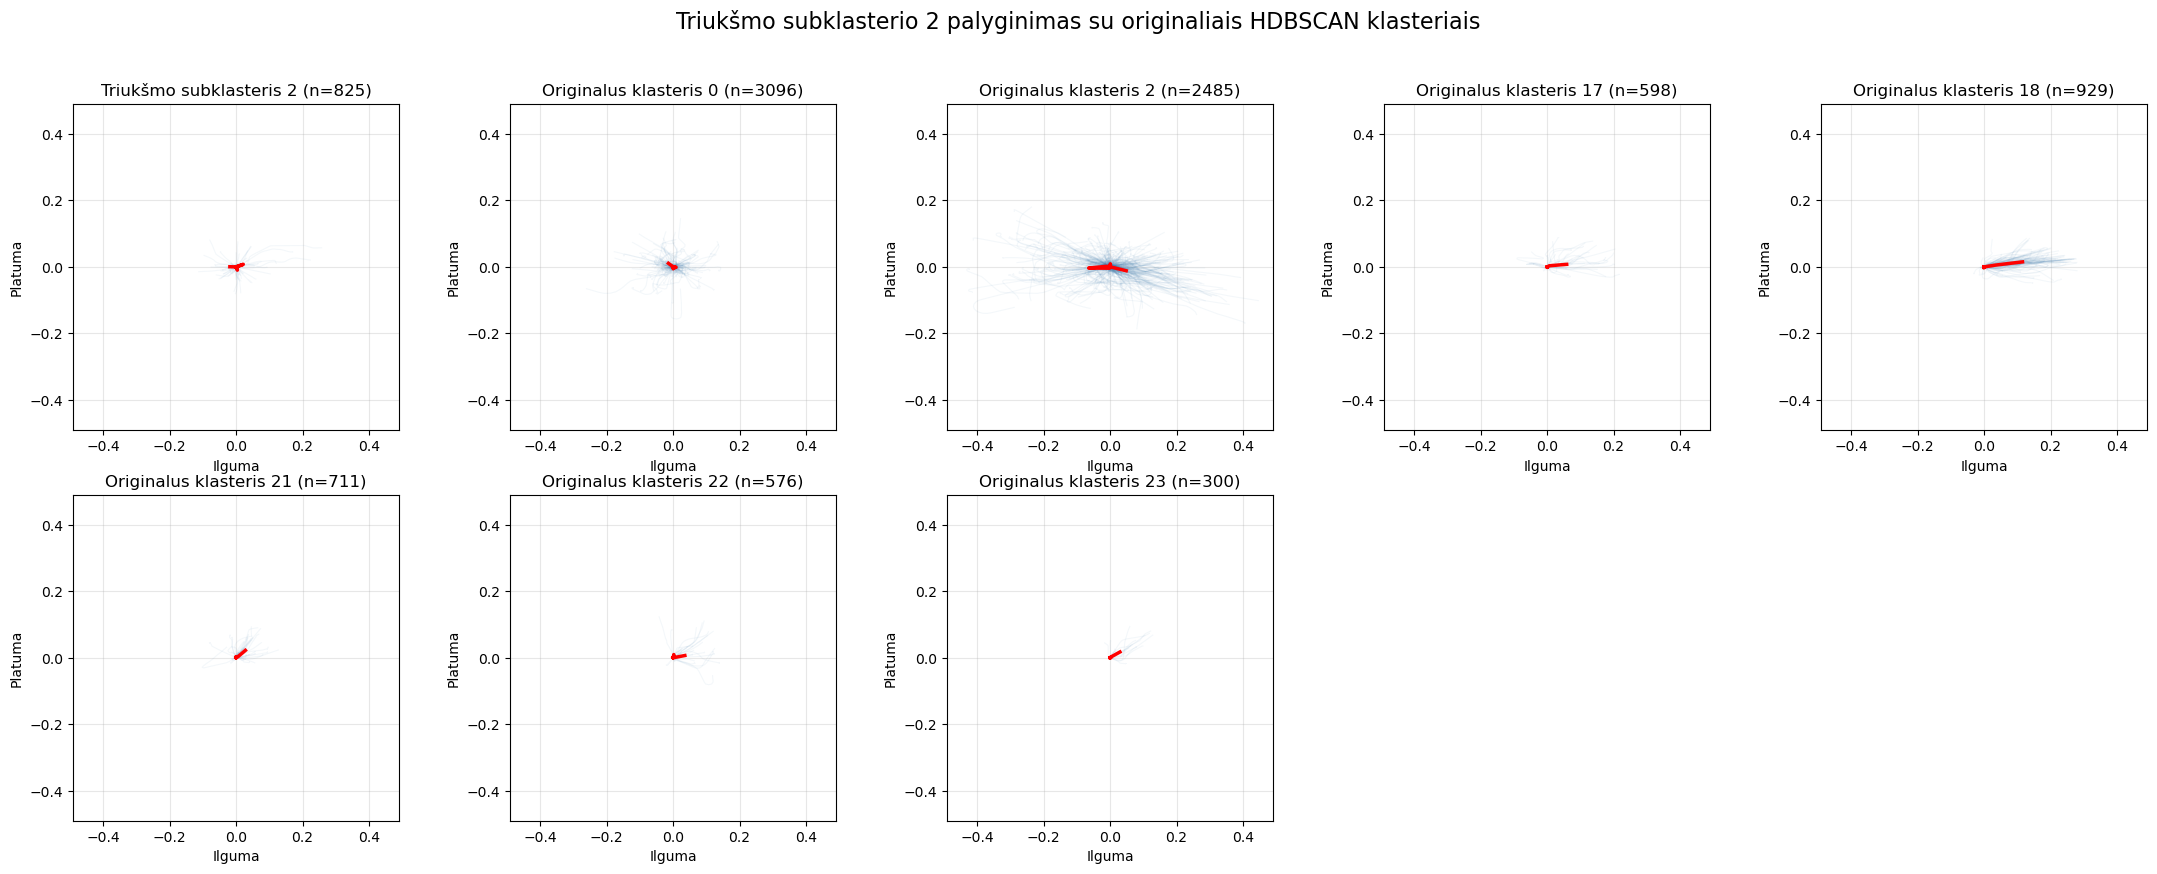

In [6]:
def plot_group(ax, X_group, title, max_for_bary=300):
    rng = np.random.default_rng(42)

    for i in range(len(X_group)):
        coords = X_group[i]

        y = coords[:, 0]
        x = coords[:, 1]

        valid = np.isfinite(x) & np.isfinite(y)

        if valid.any():
            ax.plot(
                x[valid],
                y[valid],
                color="steelblue",
                alpha=0.06,
                linewidth=0.8
            )

    if len(X_group) > 0:
        if len(X_group) > max_for_bary:
            idx = rng.choice(len(X_group), size=max_for_bary, replace=False)
            X_for_bary = X_group[idx, :, :2]
        else:
            X_for_bary = X_group[:, :, :2]

        barycenter = dtw_barycenter_averaging(
            X_for_bary.astype(float),
            max_iter=20
        )

        valid_bary = (
            np.isfinite(barycenter[:, 0]) &
            np.isfinite(barycenter[:, 1])
        )

        ax.plot(
            barycenter[valid_bary, 1],
            barycenter[valid_bary, 0],
            color="red",
            linewidth=2.5
        )

    ax.set_title(title)
    ax.set_xlabel("Ilguma")
    ax.set_ylabel("Platuma")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")


plot_data = []
plot_titles = []

noise_idx = noise_sub_meta["global_idx"].to_numpy()
X_noise_sub = X_raw[noise_idx].astype(np.float64)

plot_data.append(X_noise_sub)
plot_titles.append(
    f"Triukšmo subklasteris {target_noise_subcluster} (n={len(X_noise_sub)})"
)

for k in candidate_clusters:
    idx = np.where(labels_all == k)[0]
    X_k = X_raw[idx].astype(np.float64)

    plot_data.append(X_k)
    plot_titles.append(f"Originalus klasteris {k} (n={len(X_k)})")


all_y = np.concatenate([X[:, :, 0].ravel() for X in plot_data])
all_x = np.concatenate([X[:, :, 1].ravel() for X in plot_data])

valid = np.isfinite(all_x) & np.isfinite(all_y)

all_x = all_x[valid]
all_y = all_y[valid]

max_abs = max(
    abs(np.min(all_x)),
    abs(np.max(all_x)),
    abs(np.min(all_y)),
    abs(np.max(all_y))
)

pad = max(max_abs * 0.1, 0.001)

xlim = (-max_abs - pad, max_abs + pad)
ylim = (-max_abs - pad, max_abs + pad)

n_panels = len(plot_data)
n_cols = 5
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 4.4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, (X_group, title) in enumerate(zip(plot_data, plot_titles)):
    ax = axes[i]
    plot_group(ax, X_group, title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

for j in range(n_panels, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Triukšmo subklasterio 2 palyginimas su originaliais HDBSCAN klasteriais",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import gc

def clean_scaled(seq):
    seq = seq.astype(float).copy()
    seq = np.nan_to_num(seq, nan=0.0, posinf=0.0, neginf=0.0)
    return seq


def full_dtw_medoid_global_idx(global_idx_array, X_scaled):
    X_group = X_scaled[global_idx_array].astype(float)
    X_group = np.nan_to_num(X_group, nan=0.0, posinf=0.0, neginf=0.0)

    print("Skaičiuojama pilna DTW matrica. Sekų kiekis:", len(X_group))

    D = cdist_dtw(
        X_group,
        X_group,
        n_jobs=-1
    )

    dist_sum = D.sum(axis=1)

    medoid_local_idx = int(np.argmin(dist_sum))
    medoid_global_idx = int(global_idx_array[medoid_local_idx])
    medoid_distance_sum = float(dist_sum[medoid_local_idx])

    del D
    gc.collect()

    return medoid_global_idx, medoid_local_idx, medoid_distance_sum


noise_sub_meta = noise_meta[
    noise_meta["noise_subcluster"] == target_noise_subcluster
].copy()

noise_sub_global_idx = noise_sub_meta["global_idx"].to_numpy()

noise_sub_medoid_global_idx, noise_sub_medoid_local_idx, noise_sub_medoid_sum = (
    full_dtw_medoid_global_idx(
        noise_sub_global_idx,
        X_scaled
    )
)

print("\nTriukšmo subklasterio 2 pilnas medoidas:")
print("global_idx:", noise_sub_medoid_global_idx)
print("local_idx:", noise_sub_medoid_local_idx)
print("atstumų suma:", noise_sub_medoid_sum)


comparison_rows = []

for k in candidate_clusters:
    print("\n==============================")
    print("Skaičiuojamas originalus klasteris:", k)

    meta_k = full_meta[
        full_meta["hdbscan_cluster"] == k
    ].copy()

    if len(meta_k) == 0:
        print("Klasteris tuščias, praleidžiamas.")
        continue

    cluster_global_idx = meta_k["global_idx"].to_numpy()

    medoid_global_idx, medoid_local_idx, medoid_sum = full_dtw_medoid_global_idx(
        cluster_global_idx,
        X_scaled
    )

    d = dtw(
        clean_scaled(X_scaled[noise_sub_medoid_global_idx]),
        clean_scaled(X_scaled[medoid_global_idx])
    )

    comparison_rows.append({
        "klasteris": k,
        "klasterio_dydis": len(meta_k),
        "klasterio_medoid_global_idx": medoid_global_idx,
        "klasterio_medoid_local_idx": medoid_local_idx,
        "klasterio_medoid_atstumu_suma": medoid_sum,
        "triuksmo_2_medoid_global_idx": noise_sub_medoid_global_idx,
        "triuksmo_2_medoid_local_idx": noise_sub_medoid_local_idx,
        "triuksmo_2_medoid_atstumu_suma": noise_sub_medoid_sum,
        "dtw_atstumas_iki_triuksmo_2_medoido": d
    })

dtw_comparison_80_noise_2 = pd.DataFrame(comparison_rows)

dtw_comparison_80_noise_2 = (
    dtw_comparison_80_noise_2
    .sort_values("dtw_atstumas_iki_triuksmo_2_medoido")
    .reset_index(drop=True)
)

dtw_comparison_80_noise_2["dtw_atstumas_iki_triuksmo_2_medoido"] = (
    dtw_comparison_80_noise_2["dtw_atstumas_iki_triuksmo_2_medoido"]
    .round(6)
)

display(dtw_comparison_80_noise_2)

dtw_comparison_80_noise_2.to_csv(
    "triuksmo_subklasteris_2_vs_originalus_klasteriai_80_pilni_medoidai.csv",
    index=False
)

print("Išsaugota: triuksmo_subklasteris_2_vs_originalus_klasteriai_80_pilni_medoidai.csv")

Skaičiuojama pilna DTW matrica. Sekų kiekis: 825

Triukšmo subklasterio 2 pilnas medoidas:
global_idx: 7863
local_idx: 180
atstumų suma: 8534.740055961942

Skaičiuojamas originalus klasteris: 0
Skaičiuojama pilna DTW matrica. Sekų kiekis: 3096

Skaičiuojamas originalus klasteris: 2
Skaičiuojama pilna DTW matrica. Sekų kiekis: 2485

Skaičiuojamas originalus klasteris: 17
Skaičiuojama pilna DTW matrica. Sekų kiekis: 598

Skaičiuojamas originalus klasteris: 18
Skaičiuojama pilna DTW matrica. Sekų kiekis: 929

Skaičiuojamas originalus klasteris: 21
Skaičiuojama pilna DTW matrica. Sekų kiekis: 711

Skaičiuojamas originalus klasteris: 22
Skaičiuojama pilna DTW matrica. Sekų kiekis: 576

Skaičiuojamas originalus klasteris: 23
Skaičiuojama pilna DTW matrica. Sekų kiekis: 300


,klasteris,klasterio_dydis,klasterio_medoid_global_idx,klasterio_medoid_local_idx,klasterio_medoid_atstumu_suma,triuksmo_2_medoid_global_idx,triuksmo_2_medoid_local_idx,triuksmo_2_medoid_atstumu_suma,dtw_atstumas_iki_triuksmo_2_medoido
0,2,2485,30773,1492,24020.200214,7863,180,8534.740056,8.052602
1,21,711,33458,531,2275.768200,7863,180,8534.740056,9.960926
2,0,3096,30560,2144,29849.946777,7863,180,8534.740056,10.737363
3,22,576,8072,133,1488.964186,7863,180,8534.740056,11.455855
4,23,300,3188,58,482.470992,7863,180,8534.740056,11.951084
5,17,598,22263,399,1420.664964,7863,180,8534.740056,13.169835
6,18,929,823,13,2934.833475,7863,180,8534.740056,14.889755


Išsaugota: triuksmo_subklasteris_2_vs_originalus_klasteriai_80_pilni_medoidai.csv


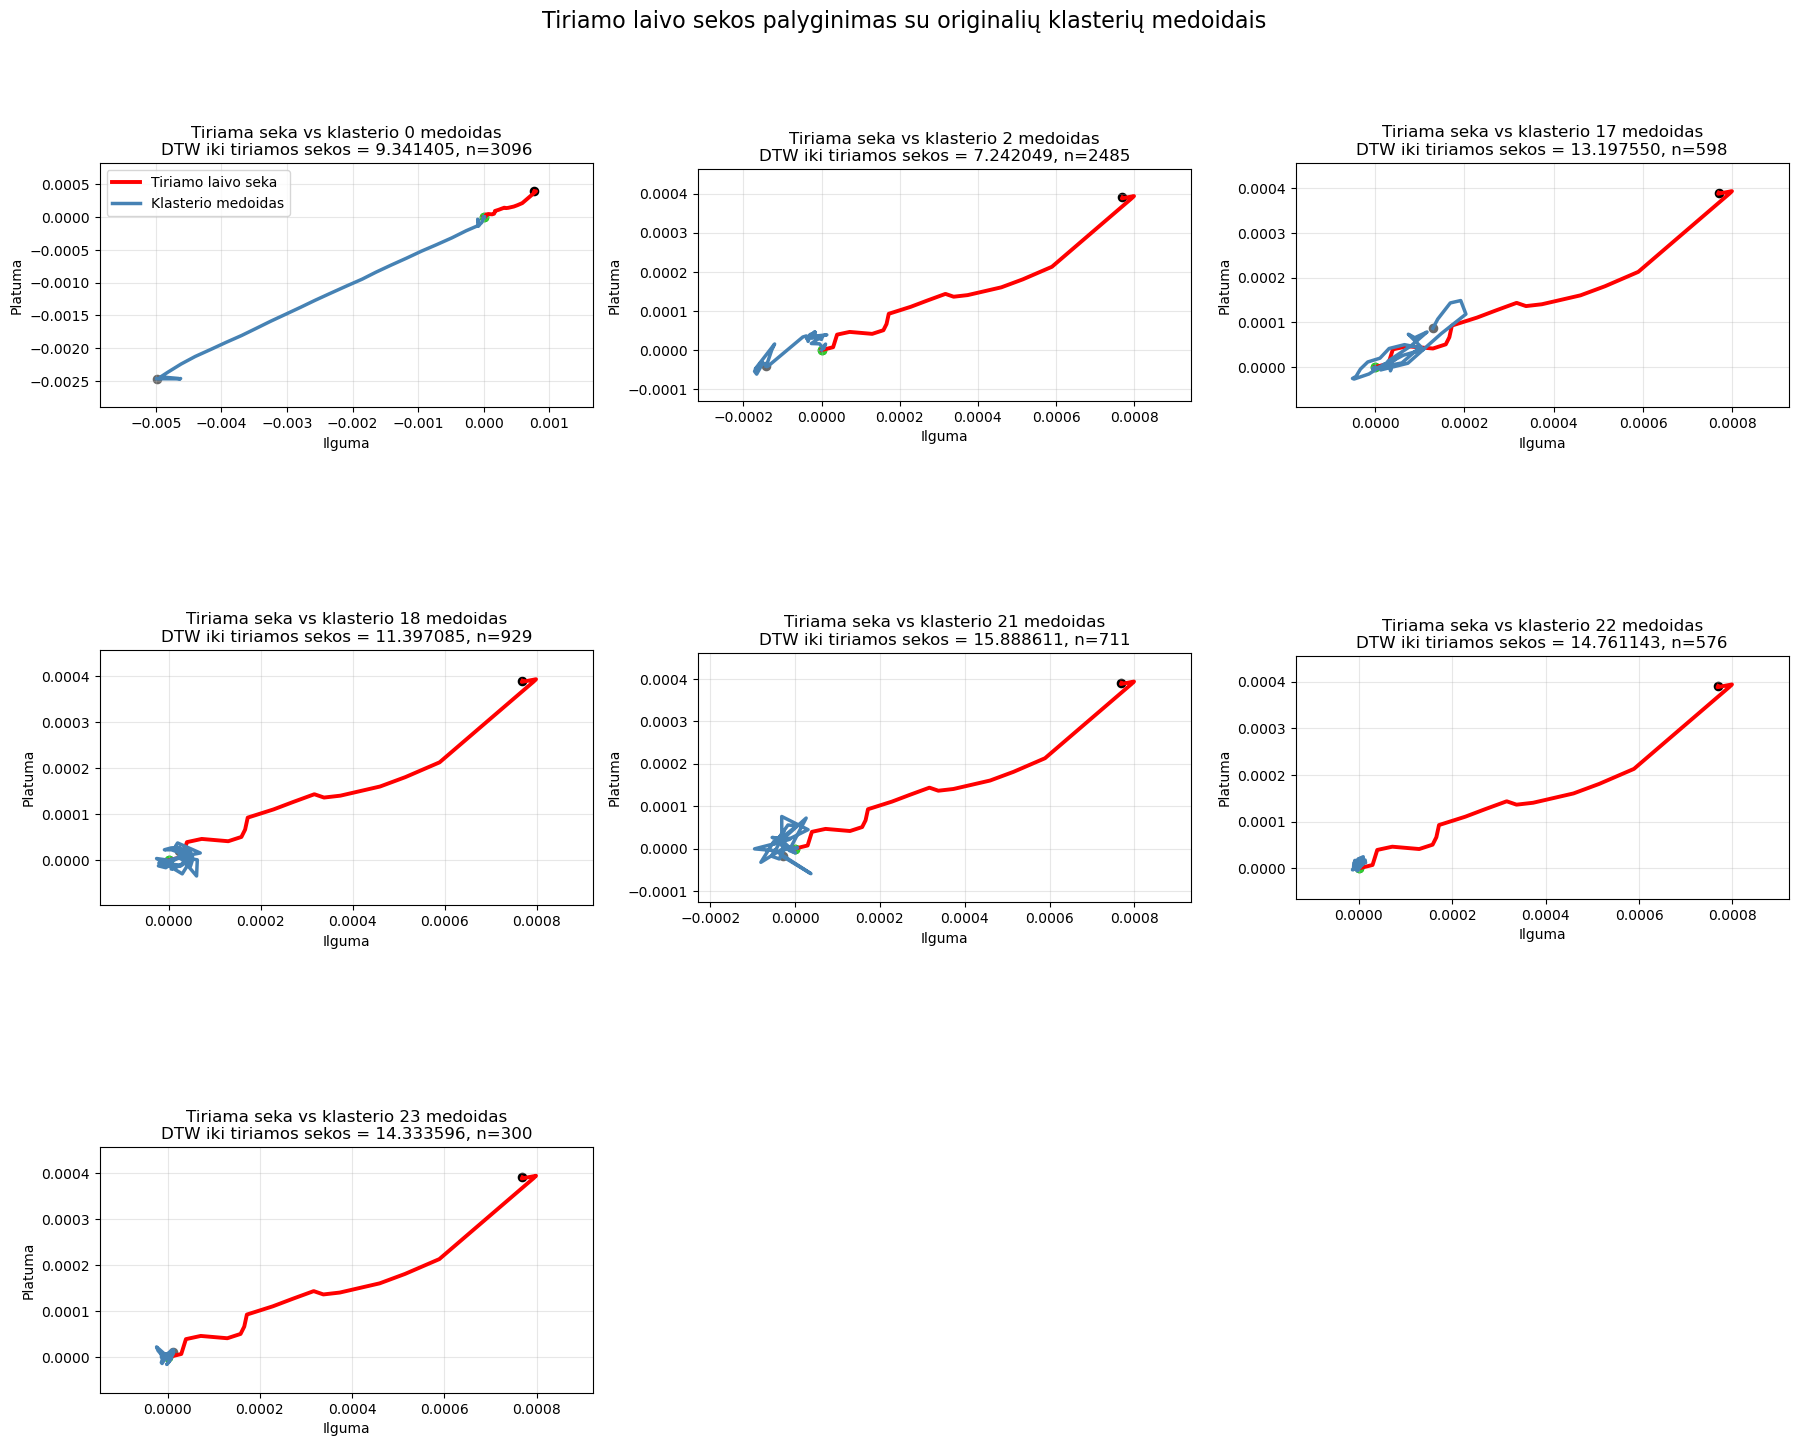

In [20]:
def clean_scaled(seq):
    seq = seq.astype(float).copy()
    seq = np.nan_to_num(seq, nan=0.0, posinf=0.0, neginf=0.0)
    return seq


def start_at_zero_raw(seq_raw):
    traj = seq_raw[:, :2].astype(float).copy()

    valid = np.isfinite(traj[:, 0]) & np.isfinite(traj[:, 1])
    traj = traj[valid]

    if len(traj) == 0:
        return traj

    traj[:, 0] -= traj[0, 0]
    traj[:, 1] -= traj[0, 1]

    return traj


target_rows = noise_meta[
    (noise_meta["mmsi"].astype(str) == str(target_mmsi)) &
    (noise_meta["noise_subcluster"] == target_noise_subcluster)
]

if len(target_rows) == 0:
    raise ValueError("Tiriamo laivo seka nerasta pasirinktame triukšmo subklasteryje.")

target_global_idx = int(target_rows["global_idx"].iloc[0])

target_seq_scaled = clean_scaled(X_scaled[target_global_idx])
target_traj = start_at_zero_raw(X_raw[target_global_idx])


medoid_rows = []

for cluster_id in candidate_clusters:
    medoid_df = pd.read_csv(f"medoid_cluster_{cluster_id}_80.csv")

    medoid_global_idx = int(medoid_df["medoid_global_idx"].iloc[0])
    n = int(medoid_df["n"].iloc[0])

    d_to_target = dtw(
        target_seq_scaled,
        clean_scaled(X_scaled[medoid_global_idx])
    )

    medoid_rows.append({
        "klasteris": cluster_id,
        "n": n,
        "medoid_global_idx": medoid_global_idx,
        "dtw_iki_tiriamos_sekos": round(d_to_target, 6)
    })

medoid_table = pd.DataFrame(medoid_rows)


n_cols = 3
n_rows = math.ceil(len(medoid_table) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5.2 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, row in medoid_table.iterrows():
    ax = axes[i]

    cluster_id = int(row["klasteris"])
    medoid_global_idx = int(row["medoid_global_idx"])

    medoid_traj = start_at_zero_raw(X_raw[medoid_global_idx])

    target_y = target_traj[:, 0]
    target_x = target_traj[:, 1]

    medoid_y = medoid_traj[:, 0]
    medoid_x = medoid_traj[:, 1]

    ax.plot(
        target_x,
        target_y,
        color="red",
        linewidth=2.8,
        label="Tiriamo laivo seka"
    )

    ax.plot(
        medoid_x,
        medoid_y,
        color="steelblue",
        linewidth=2.5,
        label="Klasterio medoidas"
    )

    ax.scatter(target_x[0], target_y[0], color="green", s=35)
    ax.scatter(target_x[-1], target_y[-1], color="black", s=35)

    ax.scatter(medoid_x[0], medoid_y[0], color="limegreen", s=35)
    ax.scatter(medoid_x[-1], medoid_y[-1], color="dimgray", s=35)

    all_x = np.concatenate([target_x, medoid_x])
    all_y = np.concatenate([target_y, medoid_y])

    xmin, xmax = np.min(all_x), np.max(all_x)
    ymin, ymax = np.min(all_y), np.max(all_y)

    pad_x = max((xmax - xmin) * 0.15, 0.00005)
    pad_y = max((ymax - ymin) * 0.15, 0.00005)

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    ax.set_title(
        f"Tiriama seka vs klasterio {cluster_id} medoidas\n"
        f"DTW iki tiriamos sekos = {row['dtw_iki_tiriamos_sekos']:.6f}, n={int(row['n'])}"
    )

    ax.set_xlabel("Ilguma")
    ax.set_ylabel("Platuma")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

    if i == 0:
        ax.legend(loc="best")


for j in range(len(medoid_table), len(axes)):
    fig.delaxes(axes[j])


fig.suptitle(
    "Tiriamo laivo sekos palyginimas su originalių klasterių medoidais",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [22]:
candidate_clusters = [0, 2, 17, 18, 21, 22, 23]
target_noise_subcluster = 2

feature_names = ["lat", "lon", "rot", "sog", "cog"]

if X_raw.shape[2] != len(feature_names):
    raise ValueError(
        f"X_raw turi {X_raw.shape[2]} požymius, o feature_names turi {len(feature_names)}."
    )

if "hdbscan_cluster" not in full_meta.columns and "cluster" in full_meta.columns:
    full_meta = full_meta.rename(columns={"cluster": "hdbscan_cluster"})

def cluster_feature_means(X_part, feature_names):
    row = {}
    
    for j, name in enumerate(feature_names):
        values = X_part[:, :, j].ravel()
        values = values[np.isfinite(values)]
        row[f"{name}_mean"] = values.mean() if len(values) > 0 else np.nan
    
    return row


rows = []

noise_sub_meta = noise_meta[
    noise_meta["noise_subcluster"] == target_noise_subcluster
].copy()

noise_sub_idx = noise_sub_meta["global_idx"].to_numpy()
X_noise_sub = X_raw[noise_sub_idx]

row = {
    "Klasteris": f"Triukšmo subkl. {target_noise_subcluster}",
    "n": len(X_noise_sub)
}
row.update(cluster_feature_means(X_noise_sub, feature_names))
rows.append(row)


for k in candidate_clusters:
    meta_k = full_meta[
        full_meta["hdbscan_cluster"] == k
    ].copy()
    
    idx = meta_k["global_idx"].to_numpy()
    X_k = X_raw[idx]
    
    row = {
        "Klasteris": k,
        "n": len(X_k)
    }
    row.update(cluster_feature_means(X_k, feature_names))
    rows.append(row)


comparison_means_80 = pd.DataFrame(rows)
comparison_means_80 = comparison_means_80.round(4)

display(comparison_means_80)



,Klasteris,n,lat_mean,lon_mean,rot_mean,sog_mean,cog_mean
0,Triukšmo subkl. 2,825,-0.0001,0.0004,0.0138,0.1689,194.327194
1,0,3096,-0.0001,0.0000,0.0101,0.2297,182.599304
2,2,2485,-0.0001,-0.0010,-0.0053,0.7247,185.782394
3,17,598,0.0007,0.0029,-0.0084,0.2077,59.684299
4,18,929,0.0012,0.0101,-0.0026,0.4823,75.171700
5,21,711,0.0011,0.0011,0.0038,0.1354,59.671398
6,22,576,0.0006,0.0019,-0.0030,0.1464,53.920601
7,23,300,0.0010,0.0019,0.0042,0.1507,46.958500
